# Smart MCQ Solver Challenge
### DL & GenAI Project | IIT Madras BS in Data Science
**Student:** Raghav Kapoor | **Roll No:** 23f2002364 | **Term:** T2-2026

## Problem Statement
Given an MCQ with 5 options (A to E), predict the top 3 most probable correct answers ranked by confidence.  
Evaluated using **MAP@3** (Mean Average Precision at 3).

## Notebook Structure
1. Setup & Imports
2. EDA & Data Exploration
3. NLP Foundation — TF-IDF, Word2Vec, Cosine Similarity, MAP@3
4. Zero-shot Classification
5. RAG Pipeline — Context Augmentation
6. Model Training
   - MLP from Scratch (PyTorch)
   - Pretrained Transformer (DeBERTa v3)
   - LoRA Fine-tuning
7. Ensembling
8. Results & Error Analysis
9. Final Submission


## Installs


In [1]:
!pip install wandb -q
!pip install sentence-transformers -q
!pip install transformers datasets -q
!pip install gensim -q
!pip install peft -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

## Imports

In [ ]:
import os
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import wandb

from kaggle_secrets import UserSecretsClient

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

from gensim.models import Word2Vec

warnings.filterwarnings("ignore")

imports done
torch version: 2.10.0+cu128
GPU available: True


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## WandB Setup

In [4]:
# using kaggle secrets to avoid exposing the api key
secrets = UserSecretsClient()
wandb_key = secrets.get_secret("WANDB_API_KEY")
wandb.login(key=wandb_key)
print("wandb login successful")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f2002364 (23f2002364-iit-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb login successful


## Data Loading

In [5]:
DATA_PATH = '/kaggle/input/competitions/smart-mcq-solver-challenge/'

train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')
sample_sub = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nTrain columns: {train.columns.tolist()}")
print(f"Test columns: {test.columns.tolist()}")

Train shape: (2000, 8)
Test shape: (500, 7)

Train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
Test columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']


## Exploratory Data Analysis

Basic look of the training data

In [6]:
print("=== Sample Questions ===\n")
for i in range(3):
    print(f"Q{i+1}: {train['prompt'].iloc[i][:200]}")
    for col in ['A','B','C','D','E']:
        marker = "✓" if train['answer'].iloc[i] == col else " "
        print(f"  [{marker}] {col}: {train[col].iloc[i][:100]}")
    print()

=== Sample Questions ===

Q1: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
  [ ] A: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not ha
  [✓] B: Martin Heidegger believes that humans do not exist inside time, but that they are time. The relation
  [ ] C: Martin Heidegger does not believe in the existence of time or that it has any effect on human consci
  [ ] D: Martin Heidegger believes that the relationship between time and human existence is cyclical. The pa
  [ ] E: Martin Heidegger believes that time is an illusion, and the past, present, and future are all happen

Q2: What is accelerator-based light-ion fusion?
  [✓] A: Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particl
  [ ] B: Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particl
  [ ] C:

Answer distribution

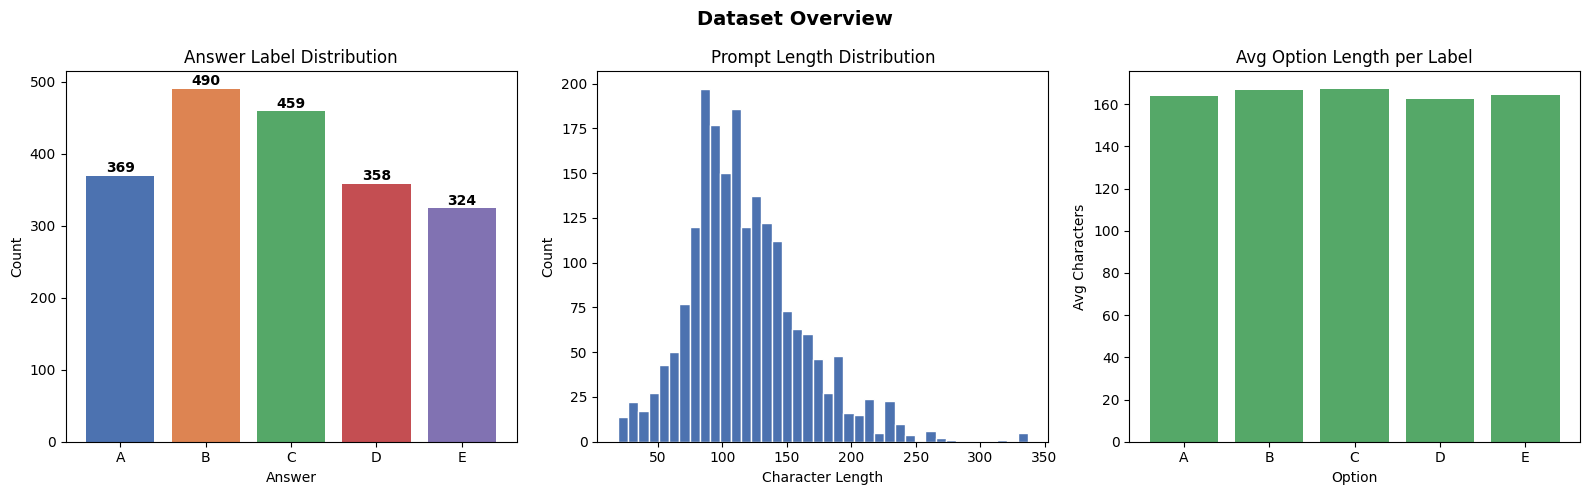

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# answer distribution
answer_counts = train['answer'].value_counts().sort_index()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
axes[0].bar(answer_counts.index, answer_counts.values, color=colors)
axes[0].set_title('Answer Label Distribution')
axes[0].set_xlabel('Answer')
axes[0].set_ylabel('Count')
for i, v in enumerate(answer_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# prompt length
train['prompt_len'] = train['prompt'].apply(len)
axes[1].hist(train['prompt_len'], bins=40, color='#4C72B0', edgecolor='white')
axes[1].set_title('Prompt Length Distribution')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Count')

# avg option length
for col in ['A','B','C','D','E']:
    train[f'{col}_len'] = train[col].apply(len)
avg_lens = [train[f'{col}_len'].mean() for col in ['A','B','C','D','E']]
axes[2].bar(['A','B','C','D','E'], avg_lens, color='#55A868')
axes[2].set_title('Avg Option Length per Label')
axes[2].set_xlabel('Option')
axes[2].set_ylabel('Avg Characters')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
train['correct_len'] = train.apply(lambda row: len(row[row['answer']]), axis=1)
wrong_lens = []
for _, row in train.iterrows():
    wrong = [len(row[col]) for col in ['A','B','C','D','E'] if col != row['answer']]
    wrong_lens.append(np.mean(wrong))
train['wrong_avg_len'] = wrong_lens


In [9]:
print("Avg length of CORRECT options:", round(train['correct_len'].mean(), 1))
print("Avg length of WRONG options:  ", round(train['wrong_avg_len'].mean(), 1))
print()


Avg length of CORRECT options: 181.9
Avg length of WRONG options:   160.7



In [10]:
print("Answer distribution (%):")
print((train['answer'].value_counts(normalize=True)*100).round(2))
print()


Answer distribution (%):
answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64



In [11]:
print("Missing values in train:", train.isnull().sum().sum())
print("Missing values in test: ", test.isnull().sum().sum())

Missing values in train: 0
Missing values in test:  0


### EDA Observations
- 2000 training samples, 500 test samples
- Answer distribution is mildly imbalanced — B is most frequent (24.5%), E least (16.2%)
- Correct and wrong options have similar average lengths, so length is not a useful signal
- Prompt lengths vary widely suggesting diverse question types and domains
- No missing values in either train or test

## MAP@3 Helper + Dummy Baseline

In [12]:
# MAP@3 utility — we'll reuse this throughout the notebook
def mapk(actual, predicted, k=3):
    """
    actual: list of true labels e.g. ['A', 'B', 'C', ...]
    predicted: list of ranked predictions e.g. [['A','B','C'], ['C','A','D'], ...]
    """
    score = 0.0
    for a, p in zip(actual, predicted):
        if a in p[:k]:
            score += 1.0 / (p[:k].index(a) + 1)
    return score / len(actual)


In [13]:
# dummy baseline — always predict A B C
dummy_preds = [['A','B','C']] * len(train)
actual = train['answer'].tolist()
dummy_map3 = mapk(actual, dummy_preds)
print(f"Dummy Baseline MAP@3: {dummy_map3:.4f}")


Dummy Baseline MAP@3: 0.3835


In [14]:
# log to wandb
run = wandb.init(
    project="23f2002364-t22026",
    entity="23f2002364-iit-madras",
    name="baseline-dummy",
    config={"model": "dummy", "strategy": "always_predict_ABC"}
)
wandb.log({"map@3": dummy_map3})
wandb.finish()
print("logged to wandb")

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260623_130909-h6cq5p85
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run baseline-dummy
wandb: ⭐️ View project at https://wandb.ai/23f2002364-iit-madras/23f2002364-t22026
wandb: 🚀 View run at https://wandb.ai/23f2002364-iit-madras/23f2002364-t22026/runs/h6cq5p85
wandb: updating run metadata; uploading summary
wandb: uploading summary
wandb: 
wandb: Run history:
wandb: map@3 ▁
wandb: 
wandb: Run summary:
wandb: map@3 0.3835
wandb: 
wandb: 🚀 View run baseline-dummy at: https://wandb.ai/23f2002364-iit-madras/23f2002364-t22026/runs/h6cq5p85
wandb: ⭐️ View project at: https://wandb.ai/23f2002364-iit-madras/23f2002364-t22026
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260623_130909-h6cq5p85/logs


logged to wandb


In [15]:
submission = pd.DataFrame({
    'ID': test['id'],
    'Prediction': 'A B C'
})
# submission.to_csv('submission_dummy.csv', index=False)
print("Dummy submission saved")
submission.head()

Dummy submission saved


,ID,Prediction
0,1,A B C
1,2,A B C
2,3,A B C
3,4,A B C
4,5,A B C


# Text Cleaning

In [16]:
import re

def clean_text(text):
    if not isinstance(text, str): 
        return ""
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text) # Remove obscure special characters/HTML
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces and newlines
    return text


In [17]:
print("Cleaning training data...")
train['prompt'] = train['prompt'].apply(clean_text)
for col in ['A', 'B', 'C', 'D', 'E']:
    train[col] = train[col].apply(clean_text)

print("Cleaning test data...")
test['prompt'] = test['prompt'].apply(clean_text)
for col in ['A', 'B', 'C', 'D', 'E']:
    test[col] = test[col].apply(clean_text)
    
print("Text cleaning complete! ✓")

Cleaning training data...
Cleaning test data...
Text cleaning complete! ✓


## Feature Extraction: Train/Val Split and Vectorization

In [18]:
# instead of combining all options together (which causes leakage),
# we score each option independently against the prompt
rows = []
for _, row in train.iterrows():
    for opt in ['A','B','C','D','E']:
        rows.append({
            'text': f"{row['prompt']} {row[opt]}",
            'label': 1 if row['answer'] == opt else 0,
            'option': opt,
            'id': row['id']
        })

In [19]:
train_pairs = pd.DataFrame(rows)
print(f"Training pairs shape: {train_pairs.shape}")
print(f"Positive examples: {train_pairs['label'].sum()}")
print(f"Negative examples: {(train_pairs['label']==0).sum()}")

Training pairs shape: (10000, 4)
Positive examples: 2000
Negative examples: 8000


In [20]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)
X_pairs = tfidf.fit_transform(train_pairs['text'])
y_pairs = train_pairs['label'].values



train_ids, val_ids = train_test_split(
    train['id'],
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [21]:
train_mask = train_pairs['id'].isin(train_ids).values  # .values here
val_mask = train_pairs['id'].isin(val_ids).values      # .values here

In [22]:
X_tr = X_pairs[train_mask]
y_tr = y_pairs[train_mask]
X_vl = X_pairs[val_mask]
y_vl = y_pairs[val_mask]

print(f"Train pairs: {X_tr.shape}")
print(f"Val pairs:   {X_vl.shape}")

Train pairs: (8000, 10000)
Val pairs:   (2000, 10000)


In [23]:
def get_top3(group):
    ranked = group.sort_values('score', ascending=False)['option'].tolist()
    return ranked[:3]

def get_top1_preds(pred_list):
    return [p[0] for p in pred_list]

val_actual = (
    train[train['id'].isin(val_ids)]
    .set_index('id')['answer']
)

# NLP Foundation — Semantic Similarity & Embeddings

### Cosine Similarity

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

# compute cosine similarity between prompt and each option
# idea: the most similar option to the prompt is likely the correct answer
def compute_cosine_scores(df):
    results = []
    for _, row in df.iterrows():
        prompt = row['prompt']
        options = [row[opt] for opt in ['A','B','C','D','E']]
        
        # fit tfidf on prompt + all options together
        texts = [prompt] + options
        tfidf_temp = TfidfVectorizer().fit(texts)
        vectors = tfidf_temp.transform(texts)
        
        # cosine similarity between prompt (index 0) and each option
        sims = cosine_similarity(vectors[0:1], vectors[1:])[0]
        results.append({
            'id': row['id'],
            'scores': sims,
            'top3': [['A','B','C','D','E'][i] for i in np.argsort(sims)[::-1][:3]]
        })
    return results

print("Computing cosine similarity on first 5 questions...")
sample_results = compute_cosine_scores(train.head(5))
for r in sample_results:
    print(f"ID {r['id']} | Scores: {dict(zip(['A','B','C','D','E'], r['scores'].round(3)))} | Top3: {r['top3']}")

Computing cosine similarity on first 5 questions...
ID 1 | Scores: {'A': np.float64(0.178), 'B': np.float64(0.199), 'C': np.float64(0.378), 'D': np.float64(0.338), 'E': np.float64(0.098)} | Top3: ['C', 'D', 'B']
ID 2 | Scores: {'A': np.float64(0.24), 'B': np.float64(0.225), 'C': np.float64(0.257), 'D': np.float64(0.208), 'E': np.float64(0.171)} | Top3: ['C', 'A', 'B']
ID 3 | Scores: {'A': np.float64(0.0), 'B': np.float64(0.0), 'C': np.float64(0.0), 'D': np.float64(0.0), 'E': np.float64(0.0)} | Top3: ['E', 'D', 'C']
ID 4 | Scores: {'A': np.float64(0.16), 'B': np.float64(0.177), 'C': np.float64(0.367), 'D': np.float64(0.337), 'E': np.float64(0.097)} | Top3: ['C', 'D', 'B']
ID 5 | Scores: {'A': np.float64(0.086), 'B': np.float64(0.086), 'C': np.float64(0.086), 'D': np.float64(0.08), 'E': np.float64(0.08)} | Top3: ['B', 'A', 'C']


In [25]:
# evaluate cosine similarity on full val set
val_train = train[train['id'].isin(val_ids)]
cosine_results = compute_cosine_scores(val_train)

cosine_preds = [r['top3'] for r in cosine_results]
cosine_actual = [train[train['id']==r['id']]['answer'].values[0] for r in cosine_results]

map3_cosine = mapk(cosine_actual, cosine_preds)
acc_cosine = sum(a == p[0] for a, p in zip(cosine_actual, cosine_preds)) / len(cosine_actual)

print(f"Cosine Similarity | Accuracy: {acc_cosine:.4f} | MAP@3: {map3_cosine:.4f}")

run = wandb.init(
    project="23f2002364-t22026",
    entity="23f2002364-iit-madras",
    name="cosine-similarity-tfidf",
    config={"model": "CosineSimilarity", "features": "TF-IDF"}
)
f1_cosine = f1_score(cosine_actual, [p[0] for p in cosine_preds], average='macro')
wandb.log({"accuracy": acc_cosine, "map@3": map3_cosine, "f1_macro": f1_cosine})
wandb.finish()

Cosine Similarity | Accuracy: 0.1850 | MAP@3: 0.3087


wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260623_130914-a0wxw8m2
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run cosine-similarity-tfidf
wandb: ⭐️ View project at https://wandb.ai/23f2002364-iit-madras/23f2002364-t22026
wandb: 🚀 View run at https://wandb.ai/23f2002364-iit-madras/23f2002364-t22026/runs/a0wxw8m2
wandb: updating run metadata; uploading summary
wandb: uploading wandb-metadata.json; uploading requirements.txt; uploading wandb-summary.json; uploading config.yaml
wandb: uploading history steps 0-0, summary
wandb: 
wandb: Run history:
wandb: accuracy ▁
wandb: f1_macro ▁
wandb:    map@3 ▁
wandb: 
wandb: Run summary:
wandb: accuracy 0.185
wandb: f1_macro 0.18761
wandb:    map@3 0.30875
wandb: 
wandb: 🚀 View run cosine-similarity-tfidf at: https://wandb.ai/23f2002364-iit-madras/23f2002364-t22026/runs/a0wxw8m2
wandb: ⭐️ View project at: https://wandb.ai/23f2002364-iit-madras/23f2002364-t22026
wa

## Word2Vec Embeddings
Generating Word2Vec emebeddings for prompt-option pairs as an alternative to TF-IDF

In [26]:
# Simple word-level tokenizer for text preprocessing — used for Word2Vec training.

def tokenize(text):
    return re.findall(r'\w+', text.lower())

In [27]:
# tokenize all text for word2vec training
w2v_sentences = [tokenize(text) for text in train_pairs['text'].tolist()]

w2v_model = Word2Vec(sentences=w2v_sentences, vector_size=100, window=5, min_count=2, workers=4, seed=42)
print(f"Word2Vec vocabulary size: {len(w2v_model.wv)}")

Word2Vec vocabulary size: 3071


In [28]:
def text_to_vector(text, model, dim=100):
    tokens = tokenize(text)
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

sample_vec = text_to_vector(train_pairs['text'].iloc[0], w2v_model)
print(f"Sample embedding shape: {sample_vec.shape}")
print(f"First 10 values: {sample_vec[:10]}")

Sample embedding shape: (100,)
First 10 values: [-0.30435044  0.04053358 -0.23260148 -0.16071771 -0.30439618 -0.1386483
 -0.18504076  0.6772753  -0.01130048 -0.57542944]
